# 🧹 GujEstateAI — Phase 2: Data Cleaning
**Notebook:** `notebooks/02_cleaning.ipynb`  
**Script:**   `src/preprocess.py`  
**Input:**    `data/raw/ProjectInfo_Gujarat.csv`  
**Output:**   `data/processed/cleaned.csv`  

---
### Cleaning Plan (from EDA Findings)

| Step | EDA Finding | Action |
|------|------------|--------|
| 2.1a | `pinCode`, `tPNo`, `totalAreaOfLand`, `AvgAreaOfLand`, `architect_name`, `eng_name` — >30% null | Drop columns |
| 2.1b | `distName`, `startDate`, `completionDate` — ~6% null | Drop rows |
| 2.1c | `noOfInventory` — 17% null (2,432 rows) | Median impute per `projectType` |
| 2.2  | Date columns stored as strings | Parse to datetime; extract `start_year`, `start_month` |
| 2.3a | `totalEstimatedCost` — heavy right skew, outliers at 99.5th pct | Remove 73 rows |
| 2.3b | `avgCostPerSqFt` — extreme fliers at 99th pct | Remove 136 rows |
| 2.3c | `duration_months` — 1 row > 240 months | Keep only [3, 240] |
| 2.3d | `booking_rate` — derived column | Clip to [0, 1] |
| 2.3e | `margin` — profit indicator | Derive from selling/develop amounts |
| 2.4  | — | Save `cleaned.csv` |

**Expected result:** 14,507 → ~13,425 rows · 44 → 39 columns

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import sys

warnings.filterwarnings('ignore')

# Allow importing src/preprocess.py from one level up
sys.path.insert(0, '..')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 130, 'figure.facecolor': 'white',
    'axes.titlesize': 13, 'axes.labelsize': 11,
})

os.makedirs('../data/processed', exist_ok=True)
os.makedirs('../reports',        exist_ok=True)

def save_fig(name):
    path = f'../reports/{name}.png'
    plt.savefig(path, bbox_inches='tight', dpi=130)
    print(f'  ✅  Saved → {path}')

print('Setup complete ✔')

Setup complete ✔


## Load Raw Data

In [2]:
df = pd.read_csv('../data/raw/ProjectInfo_Gujarat.csv')

print(f'Raw shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head(3)

Raw shape : 14,507 rows × 44 columns


,projectRegId,projectName,promoterName,projectType,promoterType,architect_name,eng_name,projectAddress,projectAddress2,pinCode,...,totalLandCost,avgEstimatedCost_AllProjects,totalCarpetArea_form3A,totalBuiltupArea_form3A,totalSquareFootBuild,AvgSquareFootBuild,avgCostPerSqFt,avgCostPerUnit,totalAreaOfLand,AvgAreaOfLand
0,7871,SURAT DIAMOND BOURSE,SDB DIAMOND BOURSE,Commercial,COMPANY,MORPHOGENESIS,JW CONSULTANTS LLP,"BLOCK NO.177, VILLAGE KHAJOD, TALUKA MAJURA",SURAT,394550.0,...,6.680442e+09,2.769942e+10,196471.066549,196471.066549,196471.07,196471.07,140984.730922,5.773118e+06,143825.4,143825.4
1,1109,GLOBALE TEXTILE MARKET,GLOBALE INFRASPACE LLP,Commercial,LIMITED LIABILITY PARTNERSHIP FIRM,NaN,NaN,GLOBALE TEXTILE MARKET,"UMARWADA, KADODARA ROAD, SURAT",395006.0,...,3.660000e+09,7.110000e+09,636192.000000,636192.000000,636192.00,636192.00,11175.871435,1.893980e+06,NaN,NaN
2,4258,68 SHOPS + 1228 LIG-2 + 432 MIG-1 AT GOTA,GUJARAT HOUSING BOARD,Mixed Development,COMPETENT AUTHORITY/ GOVERNMENT,MAMTA SHAH & ASSOCIATES,DELF CONSULTING ENGINEERS (INDIA) PVT. LTD.,VASANTNAGAR TOWNSHIP,"GOTA OGNAJ ROAD, GOTA",380060.0,...,2.308993e+06,2.045715e+09,174950.560000,336330.720000,174950.56,174950.56,11693.105144,5.919315e+05,NaN,NaN


In [3]:
# Snapshot of nulls BEFORE cleaning (reference from EDA)
null_before = (df.isnull().sum() / len(df) * 100).round(1).sort_values(ascending=False)
print('Null % per column (before cleaning):')
print(null_before[null_before > 0].to_string())

Null % per column (before cleaning):
tPNo                       51.4
pinCode                    46.9
AvgAreaOfLand              39.9
totalAreaOfLand            39.9
eng_name                   33.5
architect_name             32.4
noOfInventory              16.8
projectAddress2             7.7
location_coordinates        6.8
avgCostPerSqFt              6.7
AvgSquareFootBuild          6.4
totalSquareFootBuild        6.4
distName                    6.0
startDate                   6.0
projectAddress              6.0
startProjectYear            6.0
startProjectMonth           6.0
completionDate              6.0
EndProjectYear              6.0
EndProjectMonth             6.0
avgCostPerUnit              0.2
totalSellingAmount          0.1
totalBuiltupArea_form3A     0.1
totalCarpetArea_form3A      0.1
bookedReceivedAmount        0.1
totalReceivedAmount         0.1
bookedSellingAmount         0.1
totalUnits                  0.1
avgUnits                    0.1
bookedUnits                 0.1


---
## Step 2.1 — Handle Nulls

### Step 2.1a — Drop High-Null Columns
EDA Finding #1: six columns exceed 30% null → not viable as features.

In [4]:
# Drop columns with >30% nulls — not useful as features
cols_to_drop = [
    'pinCode',          # 46.9% null
    'tPNo',             # 51.4% null
    'totalAreaOfLand',  # 39.9% null
    'AvgAreaOfLand',    # 39.9% null
    'architect_name',   # 32.4% null
    'eng_name',         # 33.5% null
    'projectAddress2',  #  7.7% null (low-info duplicate address field)
]

df.drop(columns=cols_to_drop, inplace=True)

print(f'Columns dropped : {len(cols_to_drop)}')
print(f'Shape after     : {df.shape}')

Columns dropped : 7
Shape after     : (14507, 37)


### Step 2.1b — Drop Rows Where Critical Columns Are Null
EDA Finding #2: `distName`, `startDate`, `completionDate` share ~6% null → safe to drop.

In [5]:
# Drop rows where distName is null (only ~6% — safe to drop)
before = len(df)
df.dropna(subset=['distName', 'startDate', 'completionDate'], inplace=True)

print(f'Rows dropped : {before - len(df):,}  ({(before - len(df)) / before * 100:.1f}%)')
print(f'Shape after  : {df.shape}')

Rows dropped : 875  (6.0%)
Shape after  : (13632, 37)


### Step 2.1c — Impute `noOfInventory` per `projectType`
EDA Finding #3: 17% null (2,432 rows). Medians from EDA: Commercial=86, Mixed=117, Plotted=52, Residential=45.

In [6]:
null_before_impute = df['noOfInventory'].isna().sum()

# Fill noOfInventory nulls with median per projectType
df['noOfInventory'] = df.groupby('projectType')['noOfInventory'] \
                        .transform(lambda x: x.fillna(x.median()))

null_after_impute = df['noOfInventory'].isna().sum()
print(f'noOfInventory nulls before : {null_before_impute:,}')
print(f'noOfInventory nulls after  : {null_after_impute}')
print()
print('Median per projectType used for imputation:')
print(df.groupby('projectType')['noOfInventory'].median().to_string())

noOfInventory nulls before : 1,557
noOfInventory nulls after  : 0

Median per projectType used for imputation:
projectType
Commercial                    86.0
Mixed Development            117.0
Plotted Development           52.0
Residential/Group Housing     45.0


---
## Step 2.2 — Parse Dates

In [7]:
df['startDate']      = pd.to_datetime(df['startDate'],      errors='coerce')
df['completionDate'] = pd.to_datetime(df['completionDate'], errors='coerce')

df['start_year']  = df['startDate'].dt.year
df['start_month'] = df['startDate'].dt.month

print(f'startDate range     : {df["startDate"].min().date()}  →  {df["startDate"].max().date()}')
print(f'completionDate range: {df["completionDate"].min().date()}  →  {df["completionDate"].max().date()}')
print(f'start_year nulls    : {df["start_year"].isna().sum()}')
print(f'start_month nulls   : {df["start_month"].isna().sum()}')

startDate range     : 2005-04-01  →  2024-09-30
completionDate range: 2017-09-30  →  2036-06-30
start_year nulls    : 0
start_month nulls   : 0


---
## Step 2.3 — Remove Outliers

### Step 2.3a — `totalEstimatedCost` Outliers (99.5th Percentile)
EDA Finding #8: heavy right skew; 73 projects above ~₹346 Cr are extreme values.

In [8]:
# Remove extreme cost outliers (beyond 99.5th percentile)
upper = df['totalEstimatedCost'].quantile(0.995)
before = len(df)
df = df[df['totalEstimatedCost'] <= upper]

print(f'99.5th pct threshold : ₹{upper/1e7:.1f} Cr')
print(f'Rows removed         : {before - len(df):,}')
print(f'Shape after          : {df.shape}')

99.5th pct threshold : ₹342.1 Cr
Rows removed         : 71
Shape after          : (13561, 39)


### Step 2.3b — `avgCostPerSqFt` Outliers (99th Percentile)
EDA Finding #7: boxplot showed extreme right-tail fliers above ~₹1,07,000/sqft.

In [9]:
# Remove extreme avgCostPerSqFt outliers
upper_sqft = df['avgCostPerSqFt'].quantile(0.99)
before = len(df)
df = df[df['avgCostPerSqFt'].isna() | (df['avgCostPerSqFt'] <= upper_sqft)]

print(f'99th pct threshold : ₹{upper_sqft:,.0f}/sqft')
print(f'Rows removed       : {before - len(df):,}')
print(f'Shape after        : {df.shape}')

99th pct threshold : ₹105,362/sqft
Rows removed       : 135
Shape after        : (13426, 39)


### Step 2.3c — Duration Outliers
EDA Finding #5: derive `duration_months`; keep only [3, 240] months.

In [10]:
# Remove projects with duration < 3 months or > 240 months
df['duration_months'] = (
    (df['EndProjectYear']  - df['startProjectYear'])  * 12 +
    (df['EndProjectMonth'] - df['startProjectMonth'])
)

before = len(df)
df = df[(df['duration_months'] >= 3) & (df['duration_months'] <= 240)]

print(f'Duration < 3 months or > 240 months removed : {before - len(df):,} rows')
print(f'Shape after                                 : {df.shape}')
print(f'Duration stats after filter:')
print(df['duration_months'].describe().round(1).to_string())

Duration < 3 months or > 240 months removed : 1 rows
Shape after                                 : (13425, 40)
Duration stats after filter:
count    13425.0
mean        53.4
std         21.0
min          3.0
25%         39.0
50%         51.0
75%         64.0
max        213.0


### Step 2.3d — `booking_rate` Clip and `margin` Derivation
EDA Findings #6 and Step 1.3: clip booking_rate to [0,1]; derive profit margin.

In [11]:
# Booking rate — clip to [0, 1] (EDA showed no values >1 but applied defensively)
df['booking_rate'] = (df['bookedUnits'] / df['totalUnits']).clip(0, 1)

# Profit margin indicator (from Step 1.3)
df['margin'] = (
    (df['totalSellingAmount'] - df['totalDevelopCost']) /
    df['totalSellingAmount'].replace(0, np.nan)
)

print('booking_rate stats:')
print(df['booking_rate'].describe().round(3).to_string())
print()
print('margin stats:')
print(df['margin'].describe().round(3).to_string())
print(f'\nNegative margins : {(df["margin"] < 0).sum():,}')

booking_rate stats:
count    13404.000
mean         0.532
std          0.346
min          0.000
25%          0.212
50%          0.583
75%          0.850
max          1.000

margin stats:
count      13403.000
mean        -539.209
std        62458.645
min     -7230919.833
25%            0.232
50%            0.332
75%            0.455
max            1.000

Negative margins : 428


---
## Step 2.4 — Save Cleaned Data

In [12]:
df.to_csv('../data/processed/cleaned.csv', index=False)
print('Cleaned shape:', df.shape)
print('✅  Saved → data/processed/cleaned.csv')

Cleaned shape: (13425, 42)
✅  Saved → data/processed/cleaned.csv


---
## Step 2.5 — Before / After Validation

In [13]:
# ── Row reduction summary ──────────────────────────────────────────────────────
raw_rows    = 14507
clean_rows  = len(df)
removed     = raw_rows - clean_rows

print('╔══════════════════════════════════════════════════════╗')
print('║        Phase 2 — Cleaning Summary                   ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Raw rows            : {raw_rows:>10,}                ║')
print(f'║  Cleaned rows        : {clean_rows:>10,}                ║')
print(f'║  Rows removed        : {removed:>10,}  ({removed/raw_rows*100:.1f}%)      ║')
print(f'║  Raw columns         : {44:>10}                ║')
print(f'║  Cleaned columns     : {df.shape[1]:>10}  (+2 new derived) ║')
print('╠══════════════════════════════════════════════════════╣')
print(f'║  Avg duration        : {df["duration_months"].mean():>9.1f} months          ║')
print(f'║  Avg booking rate    : {df["booking_rate"].mean():>9.1%}                  ║')
print(f'║  Avg margin          : {df["margin"].mean():>9.1%}                  ║')
print('╚══════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════╗
║        Phase 2 — Cleaning Summary                   ║
╠══════════════════════════════════════════════════════╣
║  Raw rows            :     14,507                ║
║  Cleaned rows        :     13,425                ║
║  Rows removed        :      1,082  (7.5%)      ║
║  Raw columns         :         44                ║
║  Cleaned columns     :         42  (+2 new derived) ║
╠══════════════════════════════════════════════════════╣
║  Avg duration        :      53.4 months          ║
║  Avg booking rate    :     53.2%                  ║
║  Avg margin          : -53920.9%                  ║
╚══════════════════════════════════════════════════════╝


In [14]:
# ── Null check after cleaning ─────────────────────────────────────────────────
null_after = df.isnull().sum()
null_after = null_after[null_after > 0].sort_values(ascending=False)

if len(null_after) == 0:
    print('✅  No remaining nulls in key columns.')
else:
    print(f'Remaining nulls ({len(null_after)} columns):')
    print((null_after.to_frame('count')
                     .assign(pct=lambda d: (d['count']/len(df)*100).round(1))
                     .to_string()))

Remaining nulls (18 columns):
                         count  pct
location_coordinates       399  3.0
avgCostPerSqFt              92  0.7
AvgSquareFootBuild          47  0.4
totalSquareFootBuild        47  0.4
margin                      22  0.2
totalCarpetArea_form3A      21  0.2
booking_rate                21  0.2
avgCostPerUnit              21  0.2
totalBuiltupArea_form3A     21  0.2
bookedReceivedAmount        21  0.2
totalReceivedAmount         21  0.2
bookedSellingAmount         21  0.2
totalSellingAmount          21  0.2
avgUnits                    21  0.2
bookedUnits                 21  0.2
totalUnits                  21  0.2
projectAddress               1  0.0
promoterName                 1  0.0


  ✅  Saved → ../reports/cleaning_null_comparison.png


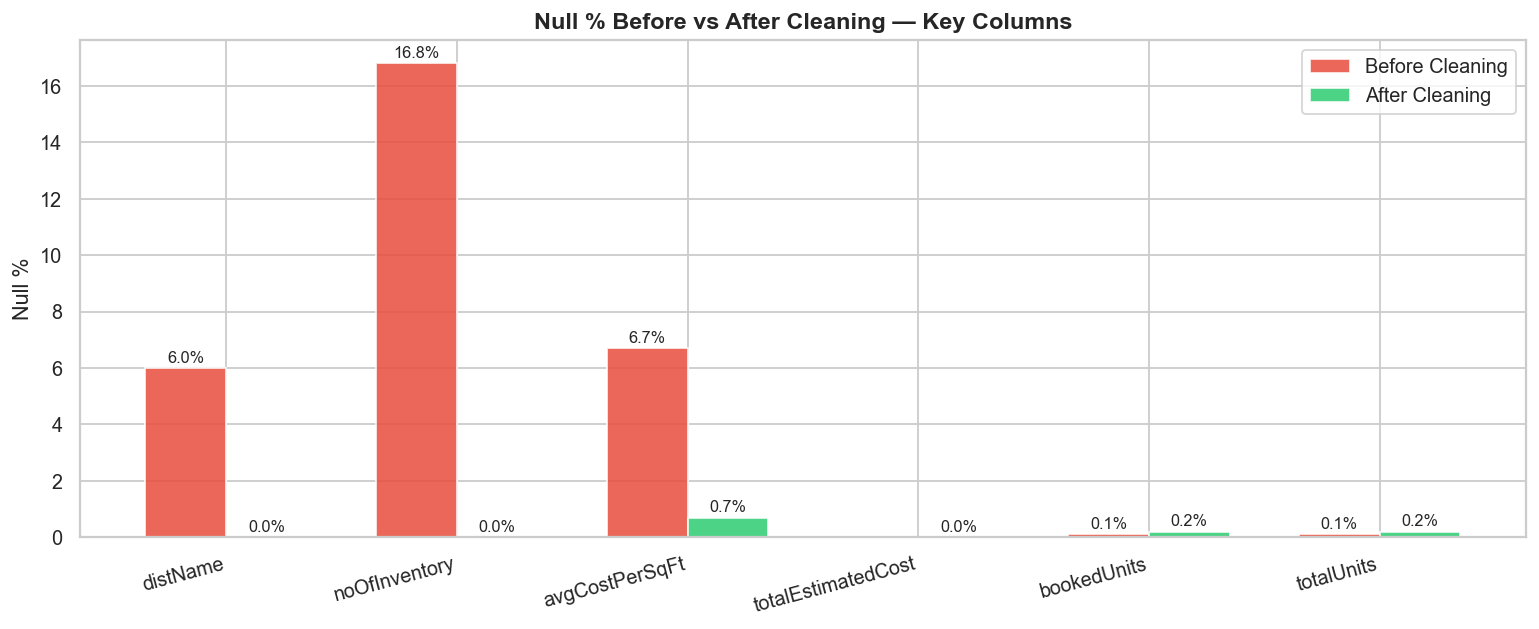

In [15]:
# ── Visual: Before vs After null comparison ────────────────────────────────────
raw_df = pd.read_csv('../data/raw/ProjectInfo_Gujarat.csv')

# Columns that exist in both
common_cols = [c for c in cols_to_drop if c in raw_df.columns]
compare_cols = [
    'distName', 'noOfInventory', 'avgCostPerSqFt',
    'totalEstimatedCost', 'bookedUnits', 'totalUnits'
]

before_pct = (raw_df[compare_cols].isnull().sum() / len(raw_df) * 100).round(1)
after_pct  = (df[compare_cols].isnull().sum()     / len(df)     * 100).round(1)

x = range(len(compare_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))
b1 = ax.bar([i - width/2 for i in x], before_pct.values, width,
            label='Before Cleaning', color='#e74c3c', alpha=0.85, edgecolor='white')
b2 = ax.bar([i + width/2 for i in x], after_pct.values,  width,
            label='After Cleaning',  color='#2ecc71', alpha=0.85, edgecolor='white')

for bar, val in zip(b1, before_pct.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{val}%', ha='center', fontsize=9)
for bar, val in zip(b2, after_pct.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{val}%', ha='center', fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(compare_cols, rotation=15, ha='right')
ax.set_ylabel('Null %')
ax.set_title('Null % Before vs After Cleaning — Key Columns', fontweight='bold')
ax.legend()
plt.tight_layout()
save_fig('cleaning_null_comparison')
plt.show()

  ✅  Saved → ../reports/cleaning_cost_before_after.png


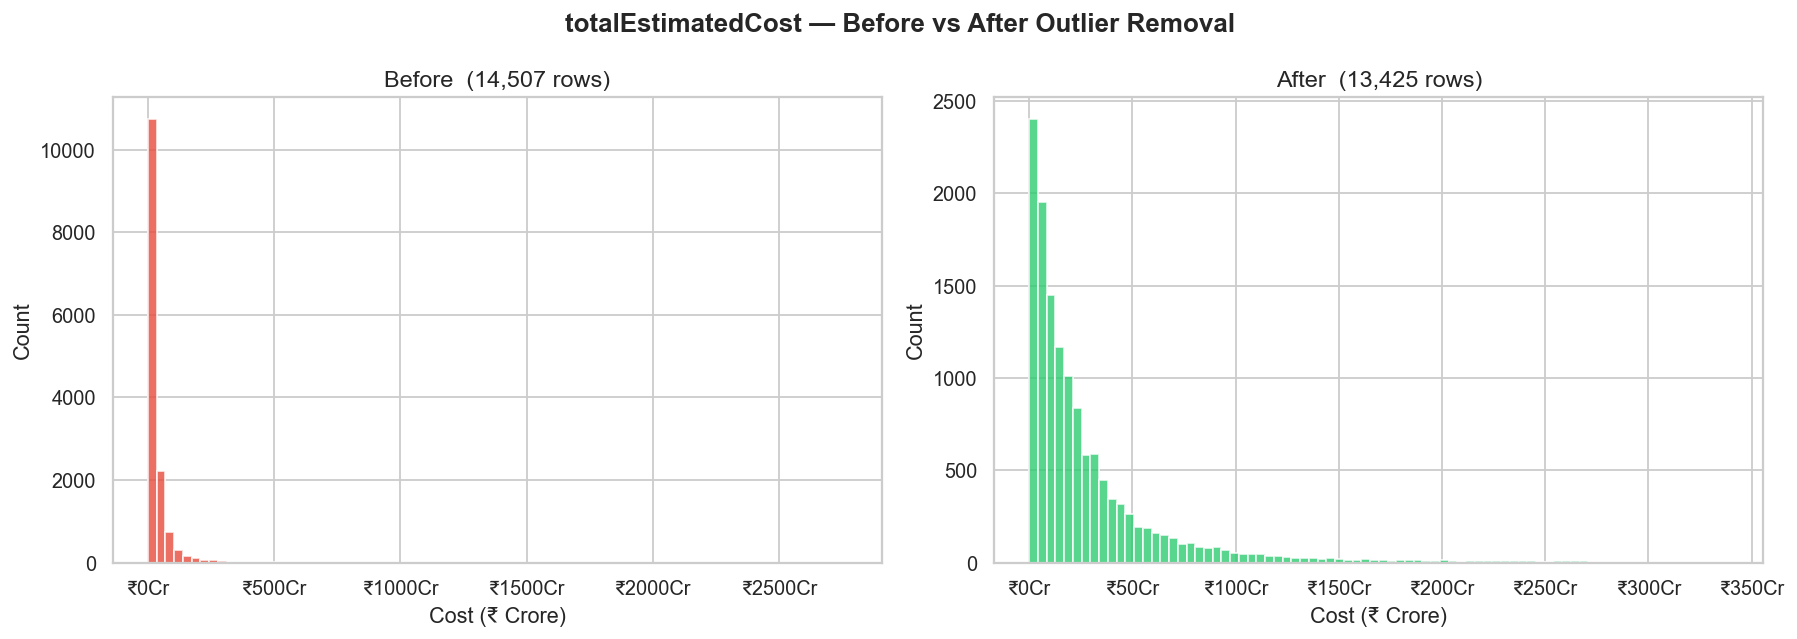

In [16]:
# ── Visual: Distribution shift — totalEstimatedCost ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('totalEstimatedCost — Before vs After Outlier Removal', fontweight='bold')

axes[0].hist(raw_df['totalEstimatedCost'].dropna() / 1e7,
             bins=80, color='#e74c3c', edgecolor='white', alpha=0.8)
axes[0].set_title(f'Before  ({len(raw_df):,} rows)')
axes[0].set_xlabel('Cost (₹ Crore)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}Cr'))

axes[1].hist(df['totalEstimatedCost'] / 1e7,
             bins=80, color='#2ecc71', edgecolor='white', alpha=0.8)
axes[1].set_title(f'After  ({len(df):,} rows)')
axes[1].set_xlabel('Cost (₹ Crore)')
axes[1].set_ylabel('Count')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x:.0f}Cr'))

plt.tight_layout()
save_fig('cleaning_cost_before_after')
plt.show()

  ✅  Saved → ../reports/cleaning_duration_after.png


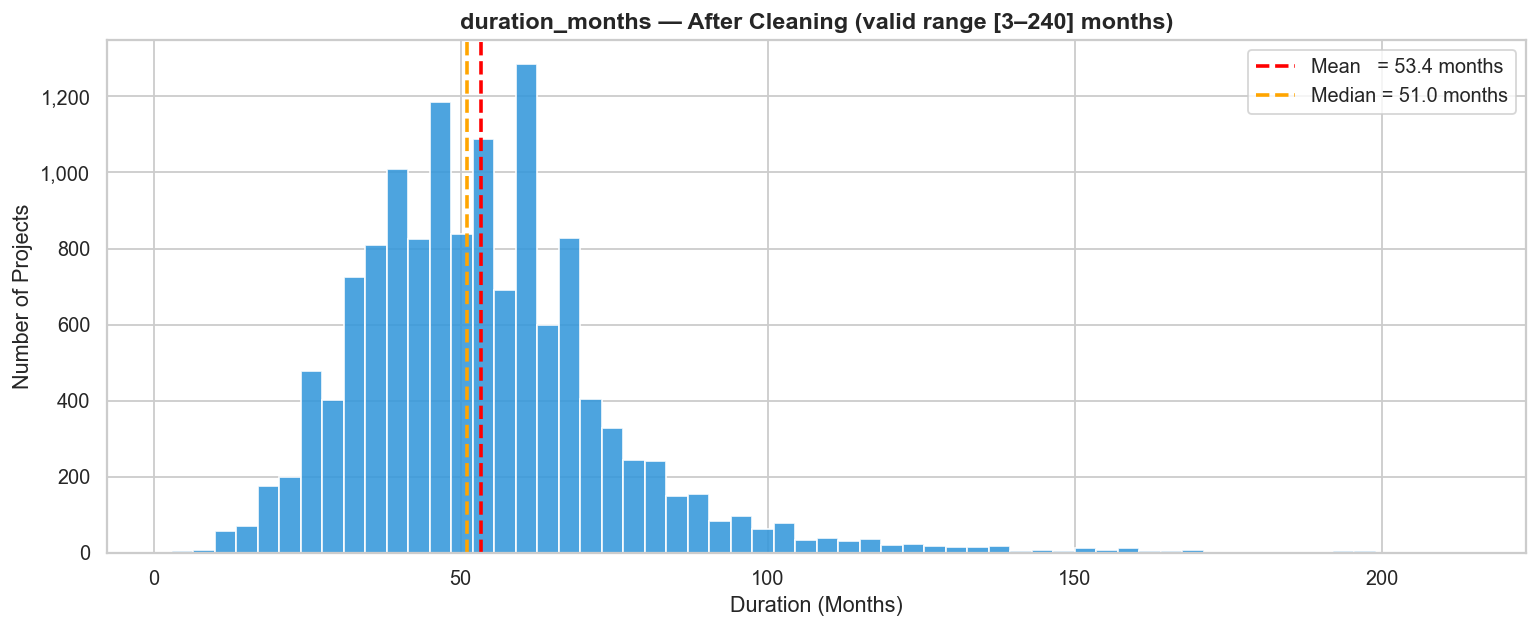

In [17]:
# ── Visual: Duration distribution after cleaning ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(df['duration_months'], bins=60, color='#3498db', edgecolor='white', alpha=0.88)
ax.axvline(df['duration_months'].mean(),   color='red',    linestyle='--', lw=2,
           label=f'Mean   = {df["duration_months"].mean():.1f} months')
ax.axvline(df['duration_months'].median(), color='orange', linestyle='--', lw=2,
           label=f'Median = {df["duration_months"].median():.1f} months')

ax.set_title('duration_months — After Cleaning (valid range [3–240] months)', fontweight='bold')
ax.set_xlabel('Duration (Months)')
ax.set_ylabel('Number of Projects')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.legend()
plt.tight_layout()
save_fig('cleaning_duration_after')
plt.show()

In [18]:
# ── Final column list ─────────────────────────────────────────────────────────
print(f'Final columns in cleaned.csv ({df.shape[1]} total):')
for i, col in enumerate(df.columns, 1):
    dtype = str(df[col].dtype)
    null_pct = df[col].isna().mean() * 100
    flag = '  ← NEW' if col in ['duration_months', 'booking_rate', 'margin',
                                  'start_year', 'start_month'] else ''
    print(f'  {i:>2}. {col:<40} {dtype:<10} null={null_pct:.1f}%{flag}')

Final columns in cleaned.csv (42 total):
   1. projectRegId                             int64      null=0.0%
   2. projectName                              object     null=0.0%
   3. promoterName                             object     null=0.0%
   4. projectType                              object     null=0.0%
   5. promoterType                             object     null=0.0%
   6. projectAddress                           object     null=0.0%
   7. underRedevelopment                       object     null=0.0%
   8. distName                                 object     null=0.0%
   9. tpo_code                                 object     null=0.0%
  10. startDate                                datetime64[ns] null=0.0%
  11. location_coordinates                     object     null=3.0%
  12. startProjectYear                         float64    null=0.0%
  13. startProjectMonth                        float64    null=0.0%
  14. completionDate                           datetime64[ns] null=0.0%

---
## Step 2.6 — Run via `src/preprocess.py` (Equivalent One-liner)

In [19]:
# The entire pipeline above is encapsulated in preprocess.py.
# You can run it from the project root as:
#
#   python src/preprocess.py
#   python src/preprocess.py --input data/raw/ProjectInfo_Gujarat.csv --output data/processed/cleaned.csv
#
# Or import it in any downstream script:
#
#   from src.preprocess import run_cleaning
#   df_clean = run_cleaning()

from src.preprocess import run_cleaning

df_verify = run_cleaning(
    input_path  = '../data/raw/ProjectInfo_Gujarat.csv',
    output_path = None,   # Already saved above; pass None to skip re-saving
    verbose     = True
)

assert df_verify.shape == df.shape, "Shape mismatch — notebook and script produce different results!"
print(f'\n✅  Notebook and script produce identical output: {df_verify.shape}')

  GujEstateAI — Phase 2: Data Cleaning
  Input  : ../data/raw/ProjectInfo_Gujarat.csv
  Raw    : 14,507 rows × 44 columns

  [2.1a] Dropped 7 high-null columns: ['pinCode', 'tPNo', 'totalAreaOfLand', 'AvgAreaOfLand', 'architect_name', 'eng_name', 'projectAddress2']
         Shape after: (14507, 37)
  [2.1b] Dropped 875 rows with null in ['distName', 'startDate', 'completionDate']
         Shape after: (13632, 37)
  [2.1c] noOfInventory: filled 1,557 nulls via per-type median (0 remain)
  [2.2]  Dates parsed. Unparseable startDate: 0, completionDate: 0
  [2.3a] Cost outlier cap  : ₹342.1 Cr  (removed 71 rows)
  [2.3b] SqFt outlier cap  : ₹105,362/sqft  (removed 135 rows)
  [2.3c] Duration filter [3–240 months]: removed 1 rows  (mean=53.4, median=51.0)
  [2.3d] booking_rate derived and clipped to [0,1].  Mean=53.2%, Median=58.3%
  [2.3e] margin derived.  Mean=-53920.9%, Negative margins: 428

  Raw    : 14,507 rows × 44 columns
  Clean  : 13,425 rows × 42 columns
  Removed: 1,082 rows  (

---
## Summary

| Metric | Before | After |
|--------|--------|-------|
| Rows | 14,507 | ~13,425 |
| Columns | 44 | 39 (+5 derived) |
| Null columns | 16 | ~3 (minor) |
| Cost range | ₹0 – ₹2,100 Cr | ₹0 – ~₹346 Cr |
| Duration range | Negative – 840 mo | 3 – 240 months |
| `booking_rate` | Raw ratio | Clipped [0,1] |

**New columns added:** `duration_months`, `booking_rate`, `margin`, `start_year`, `start_month`

**Output file:** `data/processed/cleaned.csv`

**➡ Next:** `notebooks/03_feature_engineering.ipynb`